#  Task: Predictive Modeling and Optimization in Logistics Systems

## Logistics Data Analyst Internship — Yuva Intern

### Project Title
Predictive Modeling of Delivery Time and Optimization of Logistics Operations

## 1. Problem Definition

Timely delivery is a critical component of logistics performance because delivery duration can influence service reliability, resource utilization, transportation planning, operational costs, and customer experience. The purpose of this project is to develop a predictive modeling framework that estimates the delivery time of individual shipments using relevant operational and shipment-level characteristics.

The target variable for the predictive analysis is **Delivery_Time_Hours**, representing the total simulated delivery duration of a shipment.

Potential predictor variables will include shipment distance, shipment volume, transportation mode, shipment priority, warehouse processing time, region, and other operational characteristics that would reasonably be available when planning a shipment.

The analysis will compare multiple predictive modeling techniques rather than selecting a model in advance. A simple baseline and Linear Regression will provide interpretable reference performance, while Decision Tree and Random Forest models will be evaluated for their ability to capture nonlinear relationships and interactions.

Model performance will be assessed using **Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²)**. Cross-validation and hyperparameter tuning will also be used to evaluate model stability and improve model selection.

The predictive results will then be translated into logistics optimization strategies. These strategies will focus on how predicted delivery times and model insights could support shipment planning, transportation-mode decisions, warehouse processing, resource allocation, and management of shipments at risk of long delivery durations.

Because this project uses hypothetical simulated data, model performance will represent performance within the simulated analytical environment only. It will not be presented as evidence of expected accuracy in a real logistics organization.

## 2. Prediction Objective

**Prediction problem:** Estimate shipment delivery time in hours before shipment completion.

**Target variable:** Delivery_Time_Hours

**Problem type:** Supervised machine learning — Regression

**Primary analytical question:**  
How accurately can shipment-level operational characteristics predict delivery time, and how can these predictions be used to support logistics planning and operational optimization?

## 3. Modeling and Evaluation Plan

The project will:

1. Simulate and validate a hypothetical logistics dataset.
2. Perform exploratory analysis relevant to the prediction problem.
3. Prepare numerical and categorical features for machine learning.
4. Establish a simple baseline prediction.
5. Train and evaluate Linear Regression.
6. Train and evaluate a Decision Tree Regressor.
7. Train and evaluate a Random Forest Regressor.
8. Compare models using MAE, RMSE, and R².
9. Apply cross-validation to assess model stability.
10. Perform hyperparameter tuning where appropriate.
11. Evaluate the selected model using diagnostic visualizations.
12. Analyze model drivers using appropriate feature-importance or coefficient methods.
13. Develop scenario-based logistics optimization strategies from the predictive results.
14. Discuss feasibility, limitations, and requirements for real-world implementation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 4. Hypothetical Dataset Design

A hypothetical shipment-level logistics dataset will be generated for this project. Each row will represent one shipment, and the dataset will contain operational characteristics that could reasonably influence delivery duration.

The simulated dataset is designed specifically for a regression problem in which **Delivery_Time_Hours** is the prediction target.

### Planned Variables

| Variable | Type | Role | Logistics Meaning |
|---|---|---|---|
| Shipment_ID | Identifier | Reference only | Unique shipment identifier |
| Shipment_Date | Date | Context | Simulated shipment date |
| Region | Categorical | Predictor | Shipment operating region |
| Transport_Mode | Categorical | Predictor | Road, Rail, Air, or Sea |
| Priority | Categorical | Predictor | Standard or Express shipment |
| Distance_km | Numerical | Predictor | Shipment travel distance |
| Shipment_Volume_kg | Numerical | Predictor | Shipment weight |
| Warehouse_Processing_Hours | Numerical | Predictor | Time required for warehouse processing |
| Traffic_Level | Categorical | Predictor | Simulated Low, Medium, or High traffic conditions |
| Weather_Condition | Categorical | Predictor | Simulated Clear, Rain, or Storm conditions |
| Delivery_Time_Hours | Numerical | Target | Total simulated delivery duration |

### Feature Selection Rationale

**Distance_km** is included because longer shipment routes would generally require more transit time within the simulation.

**Transport_Mode** is included because different modes operate at different simulated speeds.

**Priority** allows the model to evaluate whether Express and Standard shipments have different delivery-time patterns.

**Warehouse_Processing_Hours** represents an internal operational component that contributes to the time required to complete a shipment.

**Traffic_Level** and **Weather_Condition** introduce operational conditions that can affect simulated transit duration and allow nonlinear models to capture interactions that a simple linear model may not represent as effectively.

**Region** provides a categorical operational characteristic that can be evaluated without assuming that geographic category alone causes delivery performance.

**Shipment_Volume_kg** is included to test whether shipment size contributes useful predictive information after other operational factors are considered.

### Target Leakage Prevention

Variables that would only become known after delivery completion, or that are directly calculated from the final delivery outcome, will not be used as predictors.

For example, a post-delivery delay measure derived from actual delivery performance would create target leakage if used to predict delivery time. Such a feature could make model performance appear unrealistically strong because it would provide information that would not genuinely be available at prediction time.

The predictive feature set is therefore designed around information that could conceptually be available during shipment planning or before delivery completion.

### Simulation Boundary

The dataset is hypothetical and is being created for educational modeling purposes. Relationships introduced during simulation are designed to be plausible and analytically useful, but they do not represent measured relationships from an actual logistics organization.

In [2]:
n_shipments = 2000

shipment_ids = [f"SHP-{i:05d}" for i in range(1, n_shipments + 1)]

shipment_dates = pd.to_datetime("2025-01-01") + pd.to_timedelta(
    np.random.randint(0, 365, n_shipments), unit="D"
)

regions = np.random.choice(
    ["North", "South", "East", "West"],
    n_shipments,
    p=[0.27, 0.24, 0.25, 0.24]
)

transport_modes = np.random.choice(
    ["Road", "Rail", "Air", "Sea"],
    n_shipments,
    p=[0.45, 0.20, 0.20, 0.15]
)

priorities = np.random.choice(
    ["Standard", "Express"],
    n_shipments,
    p=[0.70, 0.30]
)

distance_km = np.random.randint(50, 3001, n_shipments)

shipment_volume_kg = np.clip(
    np.random.gamma(shape=2.2, scale=130, size=n_shipments),
    20,
    1600
).round(2)

warehouse_processing_hours = np.clip(
    np.random.gamma(shape=2.5, scale=1.5, size=n_shipments),
    0.5,
    15
).round(2)

traffic_levels = np.random.choice(
    ["Low", "Medium", "High"],
    n_shipments,
    p=[0.30, 0.45, 0.25]
)

weather_conditions = np.random.choice(
    ["Clear", "Rain", "Storm"],
    n_shipments,
    p=[0.65, 0.25, 0.10]
)

mode_speed = {
    "Road": 55,
    "Rail": 70,
    "Air": 300,
    "Sea": 35
}

traffic_effect = {
    "Low": 0.5,
    "Medium": 2.0,
    "High": 5.0
}

weather_effect = {
    "Clear": 0.0,
    "Rain": 2.0,
    "Storm": 6.0
}

region_effect = {
    "North": 0.5,
    "South": 1.0,
    "East": 1.5,
    "West": 0.8
}

priority_effect = {
    "Standard": 1.5,
    "Express": -1.5
}

base_transit_time = np.array([
    distance_km[i] / mode_speed[transport_modes[i]]
    for i in range(n_shipments)
])

delivery_time_hours = (
    2.0
    + base_transit_time
    + 0.75 * warehouse_processing_hours
    + np.array([traffic_effect[x] for x in traffic_levels])
    + np.array([weather_effect[x] for x in weather_conditions])
    + np.array([region_effect[x] for x in regions])
    + np.array([priority_effect[x] for x in priorities])
    + 0.0015 * shipment_volume_kg
    + np.random.normal(0, 3.0, n_shipments)
)

delivery_time_hours = np.clip(delivery_time_hours, 1, None).round(2)

df = pd.DataFrame({
    "Shipment_ID": shipment_ids,
    "Shipment_Date": shipment_dates,
    "Region": regions,
    "Transport_Mode": transport_modes,
    "Priority": priorities,
    "Distance_km": distance_km,
    "Shipment_Volume_kg": shipment_volume_kg,
    "Warehouse_Processing_Hours": warehouse_processing_hours,
    "Traffic_Level": traffic_levels,
    "Weather_Condition": weather_conditions,
    "Delivery_Time_Hours": delivery_time_hours
})

print("Dataset created successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset created successfully.
Dataset shape: (2000, 11)


,Shipment_ID,Shipment_Date,Region,Transport_Mode,Priority,Distance_km,Shipment_Volume_kg,Warehouse_Processing_Hours,Traffic_Level,Weather_Condition,Delivery_Time_Hours
0,SHP-00001,2025-04-13,East,Road,Standard,706,359.13,4.20,Medium,Clear,21.72
1,SHP-00002,2025-12-15,West,Road,Standard,1163,364.65,4.04,Medium,Clear,27.29
2,SHP-00003,2025-09-28,North,Road,Standard,2037,160.42,3.71,Medium,Rain,48.30
3,SHP-00004,2025-04-17,North,Road,Standard,360,137.10,2.72,Medium,Clear,18.76
4,SHP-00005,2025-03-13,North,Road,Express,606,363.86,5.62,Medium,Clear,13.38


In [3]:
print("DATASET VALIDATION")
print("------------------")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Shipment IDs:", df["Shipment_ID"].duplicated().sum())

print("\nDATA TYPES")
print(df.dtypes)

print("\nTARGET VARIABLE SUMMARY")
print(df["Delivery_Time_Hours"].describe().round(2))

DATASET VALIDATION
------------------
Rows: 2000
Columns: 11
Total missing values: 0
Duplicate rows: 0
Duplicate Shipment IDs: 0

DATA TYPES
Shipment_ID                           object
Shipment_Date                 datetime64[ns]
Region                                object
Transport_Mode                        object
Priority                              object
Distance_km                            int64
Shipment_Volume_kg                   float64
Warehouse_Processing_Hours           float64
Traffic_Level                         object
Weather_Condition                     object
Delivery_Time_Hours                  float64
dtype: object

TARGET VARIABLE SUMMARY
count    2000.00
mean       34.99
std        19.62
min         2.39
25%        18.80
50%        31.26
75%        48.37
max       105.35
Name: Delivery_Time_Hours, dtype: float64


In [4]:
dataset_path = "/content/Task_4_Hypothetical_Logistics_Dataset.csv"

df.to_csv(dataset_path, index=False)

print("Dataset saved successfully.")
print("File location:", dataset_path)

Dataset saved successfully.
File location: /content/Task_4_Hypothetical_Logistics_Dataset.csv


## 5. Exploratory Data Analysis for Predictive Modeling

Exploratory Data Analysis (EDA) is performed before model training to understand the structure, distribution, variability, and potential predictive relationships within the simulated logistics dataset.

In this project, EDA has an additional modeling purpose. It helps determine whether the selected predictors contain meaningful information about delivery time, identifies unusual distributions or extreme observations, and provides context for interpreting later model performance.

The analysis will examine the distribution of the target variable, numerical summary statistics, categorical delivery-time differences, and relationships between key operational predictors and delivery duration.

Particular attention will be given to variables such as shipment distance, transportation mode, warehouse processing time, traffic level, and weather condition because these factors were incorporated into the simulation as contributors to delivery duration.

However, exploratory relationships will not automatically be interpreted as causal effects. Because the dataset is simulated, observed patterns partly reflect the assumptions used during data generation.

The EDA will therefore serve three purposes:

1. Verify that the simulated data contains interpretable logistics patterns.
2. Support evidence-based feature and model selection.
3. Establish a transparent analytical baseline before predictive modeling begins.

In [5]:
eda_columns = [
    "Distance_km",
    "Shipment_Volume_kg",
    "Warehouse_Processing_Hours",
    "Delivery_Time_Hours"
]

descriptive_stats = df[eda_columns].describe().T

descriptive_stats["median"] = df[eda_columns].median()

descriptive_stats = descriptive_stats[
    ["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max"]
].round(2)

print("DESCRIPTIVE STATISTICS")
print("----------------------")

display(descriptive_stats)

DESCRIPTIVE STATISTICS
----------------------


,count,mean,median,std,min,25%,50%,75%,max
Distance_km,2000.0,1525.85,1522.00,854.08,50.00,779.75,1522.00,2283.25,3000.00
Shipment_Volume_kg,2000.0,287.50,246.29,190.91,20.00,145.60,246.29,389.87,1253.39
Warehouse_Processing_Hours,2000.0,3.74,3.30,2.39,0.50,2.01,3.30,4.96,15.00
Delivery_Time_Hours,2000.0,34.99,31.26,19.62,2.39,18.80,31.26,48.37,105.35


### 5.1 Interpretation of Descriptive Statistics

The descriptive statistics provide an initial quantitative view of the shipment characteristics and the delivery-time prediction target.

**Shipment distance:** The average simulated shipment distance is 1,525.85 km and the median is 1,522.00 km. The close mean and median indicate that the center of the simulated distance distribution is relatively balanced. Distances range from 50 km to 3,000 km, providing the predictive models with substantial variation across short- and long-distance shipments.

**Shipment volume:** Average shipment volume is 287.50 kg, while the median is lower at 246.29 kg. The maximum reaches 1,253.39 kg. The difference between the mean and median suggests that relatively large shipments increase the average, making it important to examine whether shipment volume provides meaningful predictive information for delivery time.

**Warehouse processing time:** Average warehouse processing time is 3.74 hours compared with a median of 3.30 hours. Processing time ranges from 0.50 to 15.00 hours. This variation is operationally relevant because warehouse processing represents a component of the simulated delivery process and may help explain differences in total delivery duration.

**Delivery time — prediction target:** Average delivery time is 34.99 hours, while the median is 31.26 hours. Delivery times range from 2.39 to 105.35 hours, with a standard deviation of 19.62 hours. The mean being higher than the median, together with the relatively large maximum, indicates that longer-duration shipments may be influencing the average. A distribution visualization will be used next to examine this pattern directly.

### Modeling Implication

The target variable shows substantial variation, which provides a meaningful regression problem rather than a nearly constant outcome. However, descriptive statistics alone cannot determine which predictors explain this variation or whether relationships are linear. Subsequent EDA and predictive modeling will therefore examine the contribution of individual operational variables and compare models with different levels of flexibility.

### 5.2 Distribution of the Prediction Target

A histogram is selected to analyze **Delivery_Time_Hours** because the target variable is continuous and the objective is to examine how frequently shipments occur across different delivery-time ranges.

Compared with a box plot, a histogram provides more direct information about the overall shape of the target distribution, including concentration, spread, asymmetry, and the presence of a long-duration tail. Mean and median reference lines are added so that the difference between these two measures of central tendency can be interpreted visually.

Understanding the target distribution is important before regression modeling because extreme or long-duration observations may affect prediction errors, particularly RMSE, which gives greater weight to larger errors.

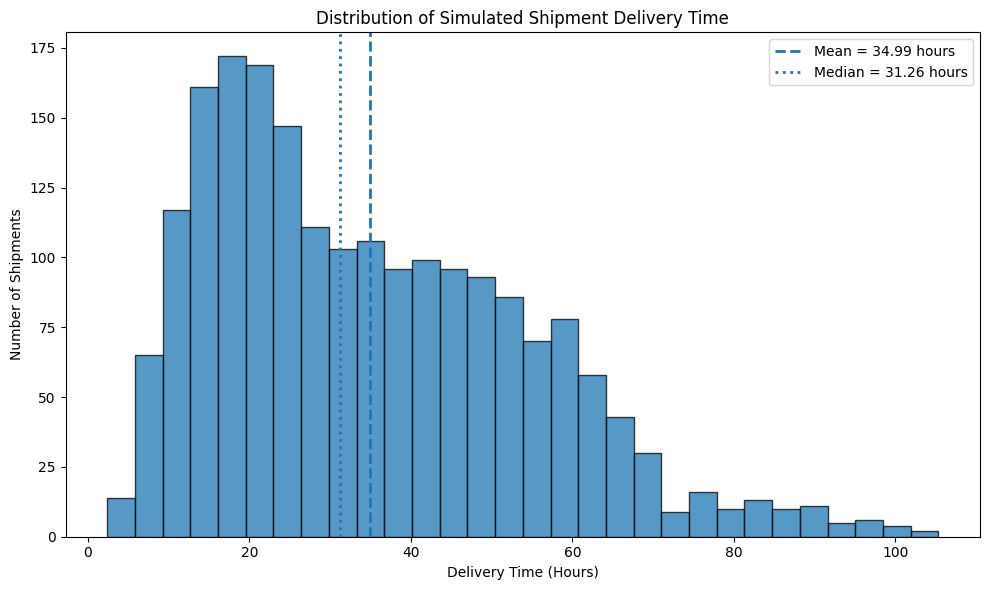

Mean delivery time: 34.99 hours
Median delivery time: 31.26 hours
Maximum delivery time: 105.35 hours


In [6]:
mean_delivery = df["Delivery_Time_Hours"].mean()
median_delivery = df["Delivery_Time_Hours"].median()

plt.figure(figsize=(10, 6))

plt.hist(
    df["Delivery_Time_Hours"],
    bins=30,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    mean_delivery,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_delivery:.2f} hours"
)

plt.axvline(
    median_delivery,
    linestyle=":",
    linewidth=2,
    label=f"Median = {median_delivery:.2f} hours"
)

plt.title("Distribution of Simulated Shipment Delivery Time")
plt.xlabel("Delivery Time (Hours)")
plt.ylabel("Number of Shipments")
plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/Task_4_Delivery_Time_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Mean delivery time:", round(mean_delivery, 2), "hours")
print("Median delivery time:", round(median_delivery, 2), "hours")
print("Maximum delivery time:", round(df["Delivery_Time_Hours"].max(), 2), "hours")

### Interpretation of Delivery Time Distribution

The histogram shows that simulated delivery time is **positively (right) skewed** rather than perfectly symmetric. A relatively large concentration of shipments occurs in the lower-to-middle delivery-time ranges, while progressively fewer shipments extend toward longer delivery durations.

This pattern is supported quantitatively by the mean delivery time of **34.99 hours**, which is higher than the median of **31.26 hours**. The maximum delivery time reaches **105.35 hours**, compared with an overall standard deviation of **19.62 hours**, confirming substantial variation in the regression target.

### Predictive Modeling Significance

The long-duration tail is important for model evaluation because prediction errors may behave differently for typical shipments and unusually long deliveries. For this reason, model performance will not be assessed using a single metric.

**MAE** will show the average absolute prediction error in hours and will provide an easily interpretable measure of typical error.

**RMSE** will place greater emphasis on larger prediction errors, making it particularly useful for identifying models that perform poorly on shipments with unusually large errors.

**R²** will measure how much of the variation in simulated delivery time is explained by the model relative to predicting around the target mean.

Using these metrics together will provide a more complete evaluation than relying on R² alone.

### Operational Interpretation

From a logistics perspective, long-duration shipments are important even when they represent a smaller part of the distribution because large delivery times can affect resource scheduling, shipment prioritization, capacity planning, and service expectations. Later model diagnostics will therefore examine whether prediction errors become larger for these shipments rather than assuming that strong average performance applies equally across the full delivery-time range.

### Limitation

The long-duration pattern reflects the assumptions used to generate the hypothetical dataset, including distance, transportation mode, warehouse processing, traffic, weather, priority, and random operational variation. It should therefore be interpreted as a simulated modeling characteristic rather than evidence about the delivery-time distribution of a real logistics organization.

In [7]:
correlation_columns = [
    "Distance_km",
    "Shipment_Volume_kg",
    "Warehouse_Processing_Hours",
    "Delivery_Time_Hours"
]

correlation_matrix = df[correlation_columns].corr().round(3)

print("CORRELATION MATRIX")
print("------------------")
display(correlation_matrix)

print("\nCORRELATION WITH DELIVERY TIME")
print("--------------------------------")
display(
    correlation_matrix["Delivery_Time_Hours"]
    .drop("Delivery_Time_Hours")
    .sort_values(ascending=False)
)

CORRELATION MATRIX
------------------


,Distance_km,Shipment_Volume_kg,Warehouse_Processing_Hours,Delivery_Time_Hours
Distance_km,1.000,-0.012,0.011,0.712
Shipment_Volume_kg,-0.012,1.000,-0.028,0.001
Warehouse_Processing_Hours,0.011,-0.028,1.000,0.084
Delivery_Time_Hours,0.712,0.001,0.084,1.000



CORRELATION WITH DELIVERY TIME
--------------------------------


,Delivery_Time_Hours
Distance_km,0.712
Warehouse_Processing_Hours,0.084
Shipment_Volume_kg,0.001


### 5.3 Numerical Predictor Correlation Analysis

Pearson correlation was used as an exploratory measure of the direction and strength of pairwise linear relationships between the numerical predictors and the delivery-time target. The results should be interpreted as descriptive associations rather than measures of causation or complete measures of predictive importance.

**Distance and delivery time (r = 0.712):**  
Shipment distance has a strong positive linear association with delivery time. Within the simulated dataset, longer-distance shipments generally require longer delivery durations. This is consistent with the simulation design, where distance contributes to transit time. However, the correlation is not perfect because the same distance can produce different delivery times depending on transport mode, warehouse processing, traffic, weather, priority, and random operational variation.

Operationally, this result suggests that distance is likely to be an important input for delivery-time planning. Nevertheless, using distance alone would ignore substantial shipment-level differences caused by other operating conditions.

**Warehouse processing time and delivery time (r = 0.084):**  
Warehouse processing time shows only a very weak positive pairwise linear association with total delivery time. This does not mean warehouse processing has no operational effect. Total delivery duration also contains a much larger transit component, particularly for long-distance shipments, which can reduce the apparent strength of the simple pairwise relationship.

The predictive models will therefore evaluate warehouse processing jointly with the other shipment characteristics rather than removing it solely because its Pearson correlation is small.

**Shipment volume and delivery time (r = 0.001):**  
Shipment volume has essentially no pairwise linear association with delivery time in this simulated dataset. This indicates that shipment weight alone provides almost no information about whether a shipment will have a longer or shorter delivery duration.

However, the variable will initially remain in the modeling feature set so that its contribution can be evaluated within the complete predictive framework. If later model diagnostics also show negligible predictive value, that would provide stronger evidence that shipment volume contributes little to this particular simulated prediction problem.

### Why Correlation Is Not the Same as Predictive Importance

Pearson correlation measures only a pairwise linear relationship. It does not capture categorical effects, nonlinear patterns, interactions between variables, or the incremental information a feature may provide after other predictors are considered.

For example, transportation mode is expected to be highly relevant to delivery time because different modes have different simulated speeds, but it does not appear in this numerical correlation table because it is categorical. Tree-based models can also capture interactions that are not summarized by a single Pearson correlation coefficient.

Therefore, correlation analysis is used here as an exploratory screening and interpretation tool, not as the sole basis for feature selection.

### Analytical Limitation

These correlations partly reflect the rules used to construct the hypothetical dataset. In particular, distance and warehouse processing were included in the delivery-time generation process. The observed coefficients therefore demonstrate whether the simulated relationships are visible in the resulting data; they should not be interpreted as empirical estimates for a real logistics organization.

### 5.4 Delivery Time by Transportation Mode

Transportation mode is a categorical predictor, so Pearson correlation is not an appropriate method for evaluating its relationship with delivery time.

A **box plot** is selected for this comparison because it shows the median, interquartile range, overall spread, and potential extreme values of delivery time separately for each transport mode. A simple bar chart of averages would hide much of this within-mode variation.

This visualization is particularly relevant to predictive modeling because transportation mode determines different simulated travel speeds. If delivery-time distributions differ substantially across modes, encoding this categorical variable should provide useful information to the regression models.

,count,mean,median,std,min,max
Transport_Mode,,,,,,
Air,378,15.36,15.42,5.32,2.39,28.95
Rail,401,32.58,32.18,12.75,6.03,62.58
Road,931,37.90,37.56,16.35,4.59,75.45
Sea,290,54.54,56.18,24.85,7.55,105.35


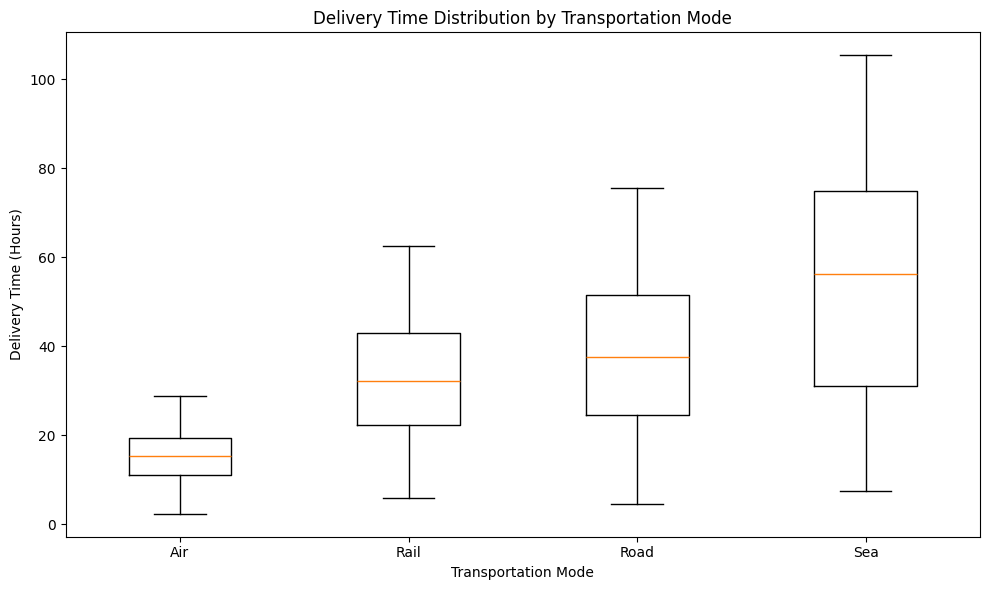

In [8]:
mode_delivery_summary = (
    df.groupby("Transport_Mode")["Delivery_Time_Hours"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
    .sort_values("mean")
)

display(mode_delivery_summary)

mode_order = mode_delivery_summary.index.tolist()

plot_data = [
    df.loc[df["Transport_Mode"] == mode, "Delivery_Time_Hours"]
    for mode in mode_order
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    plot_data,
    tick_labels=mode_order,
    showfliers=True
)

plt.title("Delivery Time Distribution by Transportation Mode")
plt.xlabel("Transportation Mode")
plt.ylabel("Delivery Time (Hours)")
plt.tight_layout()

plt.savefig(
    "/content/Task_4_Delivery_Time_by_Transport_Mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation of Delivery Time by Transportation Mode

Transportation mode shows substantial differences in both the typical level and variability of simulated delivery time.

**Air:** Air shipments have the shortest average delivery time at **15.36 hours** and a median of **15.42 hours**. They also have the lowest standard deviation at **5.32 hours**, indicating that simulated Air delivery times are relatively concentrated compared with the other modes.

**Rail:** Rail shipments have an average delivery time of **32.58 hours** and a median of **32.18 hours**, with a standard deviation of **12.75 hours**. The distribution is wider than Air, indicating greater shipment-to-shipment variation.

**Road:** Road represents the largest group with **931 shipments**. Its average delivery time is **37.90 hours**, with a median of **37.56 hours** and a standard deviation of **16.35 hours**. The wider spread indicates that Road delivery duration varies considerably across shipments.

**Sea:** Sea shipments have the longest average delivery time at **54.54 hours** and the highest median at **56.18 hours**. Sea also has the greatest variability, with a standard deviation of **24.85 hours** and delivery times extending to **105.35 hours**.

### What the Box Plot Adds Beyond an Average Comparison

A bar chart of mean delivery time would show that Air is faster on average and Sea is slower, but it would hide the variation within each mode.

The box plot provides additional information by showing differences in the median, interquartile spread, and overall delivery-time range. In particular, the increasing spread from Air toward Sea demonstrates that transportation mode is associated not only with differences in typical delivery duration but also with differences in delivery-time variability.

This distinction matters for logistics planning because two transportation options with different levels of variability may create different scheduling and service risks even if only their average delivery times are initially considered.

### Predictive Modeling Implication

The clear separation among the mode-specific delivery-time distributions suggests that **Transport_Mode** is likely to provide meaningful predictive information.

Because transportation mode is categorical, it will be converted into machine-readable indicator variables through one-hot encoding within the preprocessing pipeline. This allows the regression models to use mode information without incorrectly treating categories such as Air, Rail, Road, and Sea as a numerical ranking.

The models will evaluate transportation mode jointly with distance and the other operational predictors. This is important because the effect of shipment distance on delivery duration can differ according to transportation speed.

### Operational Interpretation

The results demonstrate a simulated time-service distinction across transportation modes. Air is associated with substantially shorter delivery durations, while Sea is associated with longer and more variable delivery durations.

These results alone are **not sufficient to recommend Air for every shipment**. A real mode-selection decision would also require transportation cost, capacity, availability, shipment characteristics, service requirements, and other operational constraints. Later optimization recommendations will therefore treat predicted delivery time as one decision input rather than the only optimization objective.

### Limitation

Transportation-mode differences are intentionally influenced by the mode-specific speeds used during dataset simulation. The results demonstrate how a predictive model can learn meaningful categorical operating differences, but they should not be interpreted as real-world performance benchmarks for Air, Rail, Road, or Sea transportation.

## 6. Data Preparation for Predictive Modeling

The predictive modeling stage uses **Delivery_Time_Hours** as the regression target.

Shipment_ID is excluded because it is an identifier rather than an operational predictor. Shipment_Date is also excluded from the initial model because the simulated dates do not contain genuine seasonal demand or operational patterns. Including arbitrary date components could introduce artificial patterns without a defensible logistics interpretation.

The selected predictors are divided into numerical and categorical variables so that each data type can be processed appropriately.

### Numerical Predictors

- Distance_km
- Shipment_Volume_kg
- Warehouse_Processing_Hours

### Categorical Predictors

- Region
- Transport_Mode
- Priority
- Traffic_Level
- Weather_Condition

Categorical variables will be transformed using **one-hot encoding**, while numerical variables will be passed through the preprocessing pipeline. The preprocessing steps will be fitted using training data rather than the complete dataset, helping prevent information from the test set from influencing model preparation.

The same train-test split will be used for all candidate models so that their performance can be compared under consistent evaluation conditions.

In [9]:
target = "Delivery_Time_Hours"

numerical_features = [
    "Distance_km",
    "Shipment_Volume_kg",
    "Warehouse_Processing_Hours"
]

categorical_features = [
    "Region",
    "Transport_Mode",
    "Priority",
    "Traffic_Level",
    "Weather_Condition"
]

feature_columns = numerical_features + categorical_features

X = df[feature_columns].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("FEATURE AND TARGET PREPARATION")
print("------------------------------")
print("Total observations:", len(df))
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
print("Number of predictor variables:", len(feature_columns))
print("Target variable:", target)

print("\nNumerical predictors:")
print(numerical_features)

print("\nCategorical predictors:")
print(categorical_features)

FEATURE AND TARGET PREPARATION
------------------------------
Total observations: 2000
Training observations: 1600
Testing observations: 400
Number of predictor variables: 8
Target variable: Delivery_Time_Hours

Numerical predictors:
['Distance_km', 'Shipment_Volume_kg', 'Warehouse_Processing_Hours']

Categorical predictors:
['Region', 'Transport_Mode', 'Priority', 'Traffic_Level', 'Weather_Condition']


In [10]:
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")
print("Numerical features: median imputation + standardization")
print("Categorical features: most-frequent imputation + one-hot encoding")

Preprocessing pipeline created successfully.
Numerical features: median imputation + standardization
Categorical features: most-frequent imputation + one-hot encoding


## 7. Baseline Model

A baseline model is established before evaluating more sophisticated regression algorithms.

The baseline uses a **DummyRegressor with the mean strategy**, which predicts the average delivery time from the training data for every test shipment. It does not learn relationships between shipment characteristics and delivery duration.

This provides a minimum reference level for predictive performance. A useful logistics prediction model should outperform this simple strategy on unseen test data.

The baseline will be evaluated using the same three metrics used for the candidate models:

- **MAE** measures the average absolute difference between predicted and actual delivery time in hours.
- **RMSE** also measures prediction error in hours but penalizes larger errors more strongly.
- **R²** compares the model with a mean-based prediction reference. A value near 0 indicates little improvement over predicting around the target mean, while higher values indicate that more variation in delivery time is explained.

Using an identical test set and identical evaluation metrics ensures that later model comparisons are based on consistent evidence.

In [11]:
baseline_model = DummyRegressor(strategy="mean")

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_r2 = r2_score(y_test, baseline_predictions)

print("BASELINE MODEL PERFORMANCE")
print("--------------------------")
print("MAE:", round(baseline_mae, 2), "hours")
print("RMSE:", round(baseline_rmse, 2), "hours")
print("R-squared:", round(baseline_r2, 3))

BASELINE MODEL PERFORMANCE
--------------------------
MAE: 16.61 hours
RMSE: 19.97 hours
R-squared: -0.0


## 8. Linear Regression Model

Linear Regression is selected as the first substantive predictive model because it provides a transparent and interpretable benchmark for evaluating whether the selected shipment characteristics contain useful predictive information.

Unlike the mean-based baseline, Linear Regression estimates delivery time from the combined contribution of numerical and encoded categorical predictors.

Its main advantage is interpretability and computational simplicity. However, it assumes that numerical predictor effects are primarily linear and additive after preprocessing. This can be restrictive in logistics data where variables may interact. For example, the relationship between shipment distance and delivery time may depend strongly on transportation mode.

The model is therefore not assumed to be the best model in advance. Its performance will be compared objectively with more flexible tree-based methods using the same test observations and evaluation metrics.

In [12]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("LINEAR REGRESSION PERFORMANCE")
print("-----------------------------")
print("MAE:", round(linear_mae, 2), "hours")
print("RMSE:", round(linear_rmse, 2), "hours")
print("R-squared:", round(linear_r2, 3))

LINEAR REGRESSION PERFORMANCE
-----------------------------
MAE: 5.1 hours
RMSE: 7.22 hours
R-squared: 0.869


## 9. Decision Tree Regression Model

A Decision Tree Regressor is evaluated as a nonlinear alternative to Linear Regression.

Decision trees repeatedly divide the feature space into groups of observations with similar target values. This allows them to capture nonlinear relationships and interactions without requiring those relationships to be specified in advance.

This flexibility is relevant to the simulated logistics problem because delivery time depends on combinations of operational factors. For example, the relationship between distance and delivery duration differs across transportation modes because each mode has a different simulated travel speed.

A key limitation is that an unrestricted decision tree can fit training data too closely and perform less effectively on unseen shipments. Therefore, the initial tree is evaluated as an untuned candidate model, and later validation results will help determine whether additional model control or tuning is necessary.

In [13]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]
)

decision_tree_model.fit(X_train, y_train)

tree_predictions = decision_tree_model.predict(X_test)

tree_mae = mean_absolute_error(y_test, tree_predictions)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_predictions))
tree_r2 = r2_score(y_test, tree_predictions)

print("DECISION TREE PERFORMANCE")
print("-------------------------")
print("MAE:", round(tree_mae, 2), "hours")
print("RMSE:", round(tree_rmse, 2), "hours")
print("R-squared:", round(tree_r2, 3))

DECISION TREE PERFORMANCE
-------------------------
MAE: 4.18 hours
RMSE: 5.32 hours
R-squared: 0.929


## 10. Random Forest Regression Model

Random Forest Regression is selected as an ensemble-based candidate model. Instead of relying on a single decision tree, Random Forest combines predictions from many trees trained on different samples and feature subsets.

This approach is relevant to the logistics prediction problem because it can capture nonlinear relationships and interactions while generally reducing the instability and overfitting risk associated with a single unrestricted decision tree.

For example, delivery time may depend on interactions between shipment distance, transportation mode, traffic conditions, weather, and warehouse processing. Random Forest can model such relationships without requiring them to be manually specified.

However, greater model complexity does not automatically mean better predictive performance. Random Forest is less directly interpretable than Linear Regression and requires more computational resources. Its suitability will therefore be determined from test performance, cross-validation stability, and later hyperparameter tuning rather than from algorithm complexity alone.

In [14]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

forest_predictions = random_forest_model.predict(X_test)

forest_mae = mean_absolute_error(y_test, forest_predictions)
forest_rmse = np.sqrt(mean_squared_error(y_test, forest_predictions))
forest_r2 = r2_score(y_test, forest_predictions)

print("RANDOM FOREST PERFORMANCE")
print("-------------------------")
print("MAE:", round(forest_mae, 2), "hours")
print("RMSE:", round(forest_rmse, 2), "hours")
print("R-squared:", round(forest_r2, 3))

RANDOM FOREST PERFORMANCE
-------------------------
MAE: 2.85 hours
RMSE: 3.61 hours
R-squared: 0.967


In [15]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Mean",
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE_Hours": [
        baseline_mae,
        linear_mae,
        tree_mae,
        forest_mae
    ],
    "RMSE_Hours": [
        baseline_rmse,
        linear_rmse,
        tree_rmse,
        forest_rmse
    ],
    "R_Squared": [
        baseline_r2,
        linear_r2,
        tree_r2,
        forest_r2
    ]
})

model_comparison["MAE_Improvement_vs_Baseline_%"] = (
    (baseline_mae - model_comparison["MAE_Hours"])
    / baseline_mae * 100
)

model_comparison["RMSE_Improvement_vs_Baseline_%"] = (
    (baseline_rmse - model_comparison["RMSE_Hours"])
    / baseline_rmse * 100
)

model_comparison = model_comparison.round({
    "MAE_Hours": 2,
    "RMSE_Hours": 2,
    "R_Squared": 3,
    "MAE_Improvement_vs_Baseline_%": 2,
    "RMSE_Improvement_vs_Baseline_%": 2
})

print("MODEL PERFORMANCE COMPARISON")
print("----------------------------")

display(model_comparison)

MODEL PERFORMANCE COMPARISON
----------------------------


,Model,MAE_Hours,RMSE_Hours,R_Squared,MAE_Improvement_vs_Baseline_%,RMSE_Improvement_vs_Baseline_%
0,Baseline Mean,16.61,19.97,-0.000,0.00,0.00
1,Linear Regression,5.10,7.22,0.869,69.29,63.86
2,Decision Tree,4.18,5.32,0.929,74.86,73.37
3,Random Forest,2.85,3.61,0.967,82.82,81.93


### 10.1 Comparative Model Performance

The four models show substantial differences in predictive performance on the same held-out test set.

The **Baseline Mean model** produces an MAE of **16.61 hours** and an RMSE of **19.97 hours**, with an R² approximately equal to zero. This represents the reference performance obtained when shipment characteristics are ignored and every test observation is predicted using the training-set mean.

**Linear Regression** substantially improves performance, reducing MAE to **5.10 hours** and RMSE to **7.22 hours**. Relative to the baseline, this represents a **69.29% reduction in MAE** and a **63.86% reduction in RMSE**. Its R² of **0.869** indicates that the model explains a large proportion of delivery-time variation within the held-out simulated test data. This demonstrates that the selected operational predictors contain substantial predictive information even under a relatively simple additive model.

The **Decision Tree** further reduces MAE to **4.18 hours** and RMSE to **5.32 hours**, corresponding to improvements of **74.86%** and **73.37%**, respectively, relative to the baseline. Its R² increases to **0.929**. The improvement over Linear Regression suggests that nonlinear relationships and interactions provide additional predictive value in the simulated logistics problem.

The **Random Forest** achieves the strongest performance on the current test split, with an MAE of **2.85 hours**, RMSE of **3.61 hours**, and R² of **0.967**. Compared with the baseline, MAE is reduced by **82.82%** and RMSE by **81.93%**.

### Why Multiple Metrics Are Necessary

The model ranking is consistent across MAE, RMSE, and R² on this test split, but each metric provides a different perspective.

MAE indicates that the Random Forest prediction differs from the actual simulated delivery time by approximately **2.85 hours on average in absolute terms**.

Its RMSE is higher at **3.61 hours**, reflecting the additional penalty placed on larger prediction errors. The difference between MAE and RMSE indicates that some prediction errors are larger than the typical absolute error, which will be investigated later through residual diagnostics.

R² of **0.967** means that approximately 96.7% of the variation in delivery time in this particular simulated test set is explained by the Random Forest relative to the mean-prediction reference. It does not mean that 96.7% of individual predictions are correct, nor does it establish equivalent accuracy on real logistics data.

### Current Model-Selection Interpretation

Based only on the held-out test set, Random Forest is the strongest candidate among the models evaluated so far. However, selecting a final model from one train-test split alone would provide incomplete evidence.

A model can perform particularly well or poorly depending on which observations happen to enter a single test sample. The next stage will therefore use **cross-validation** to evaluate performance across multiple training-validation partitions and examine whether the observed model advantage is stable.

Only after cross-validation and hyperparameter tuning will the final predictive model be selected.

### Simulation Limitation

The relatively strong model performance is partly expected because the target variable was generated from known relationships involving the predictor variables. The reported metrics therefore measure how successfully the algorithms recover patterns within this simulated environment.

These results should not be interpreted as evidence that the same models would achieve equivalent MAE, RMSE, or R² on real operational logistics data.

## 11. Cross-Validation and Model Stability

A single train-test split provides an important estimate of performance on unseen observations, but the result can depend on which shipments happen to be included in the training and test sets.

To obtain a more robust comparison, **5-fold cross-validation** is applied to Linear Regression, Decision Tree, and Random Forest using the training dataset.

In 5-fold cross-validation, the training data is divided into five subsets. Each model is trained five times, with four subsets used for training and the remaining subset used for validation in each iteration. This allows every training observation to contribute to validation once.

The analysis reports the mean cross-validation MAE and its standard deviation. Lower mean MAE indicates better average predictive accuracy, while a smaller standard deviation indicates more consistent performance across folds.

The preprocessing pipeline remains inside each model pipeline so that imputation, scaling, and one-hot encoding are fitted separately within each training fold. This helps prevent validation information from leaking into preprocessing.

In [16]:
cv_models = {
    "Linear Regression": linear_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

cv_results = []

for model_name, model in cv_models.items():
    scores = -cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "CV_MAE_Mean_Hours": scores.mean(),
        "CV_MAE_Std_Hours": scores.std(),
        "Best_Fold_MAE_Hours": scores.min(),
        "Worst_Fold_MAE_Hours": scores.max()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.round({
    "CV_MAE_Mean_Hours": 2,
    "CV_MAE_Std_Hours": 2,
    "Best_Fold_MAE_Hours": 2,
    "Worst_Fold_MAE_Hours": 2
})

print("5-FOLD CROSS-VALIDATION RESULTS")
print("-------------------------------")

display(cv_results_df)

5-FOLD CROSS-VALIDATION RESULTS
-------------------------------


,Model,CV_MAE_Mean_Hours,CV_MAE_Std_Hours,Best_Fold_MAE_Hours,Worst_Fold_MAE_Hours
0,Linear Regression,5.05,0.27,4.74,5.51
1,Decision Tree,4.24,0.18,4.00,4.41
2,Random Forest,3.10,0.11,2.91,3.22


### 11.1 Interpretation of Cross-Validation Results

The 5-fold cross-validation results provide additional evidence about predictive accuracy and model stability across different subsets of the training data.

**Linear Regression** records a mean cross-validation MAE of **5.05 hours**, with a standard deviation of **0.27 hours**. Its fold-level MAE ranges from **4.74 to 5.51 hours**. This confirms that the linear model provides reasonably consistent predictive performance, but its average error remains higher than the tree-based alternatives.

**Decision Tree** improves the mean cross-validation MAE to **4.24 hours**, with a standard deviation of **0.18 hours**. Its fold results range from **4.00 to 4.41 hours**. This supports the earlier test-set evidence that nonlinear relationships and interactions contribute useful predictive information beyond the additive structure captured by Linear Regression.

**Random Forest** achieves the lowest mean cross-validation MAE at **3.10 hours**. It also records the smallest standard deviation at **0.11 hours**, with fold-level MAE ranging only from **2.91 to 3.22 hours**.

### Accuracy and Stability Interpretation

The Random Forest result is important for two separate reasons.

First, its mean cross-validation MAE is lower than both Linear Regression and the single Decision Tree, indicating stronger average predictive accuracy across the five validation folds.

Second, its standard deviation is also the smallest. This indicates that its validation performance changes relatively little across the five partitions used in this analysis. Therefore, the model's strong performance is not limited to the particular 80/20 test split evaluated earlier.

The Random Forest mean cross-validation MAE of **3.10 hours** is also reasonably close to its held-out test MAE of **2.85 hours**. This consistency provides additional evidence that the current model generalizes well within the simulated dataset.

### Model-Selection Implication

At this stage, Random Forest is the leading candidate because it combines the lowest test-set errors, highest test-set R², lowest mean cross-validation MAE, and smallest cross-validation MAE variability among the evaluated models.

However, the current Random Forest uses largely default structural settings. Before final model selection, hyperparameter tuning will be performed to test whether a different combination of tree depth, number of trees, feature sampling, and minimum leaf size can improve or simplify the model while maintaining robust predictive performance.

### Limitation

Five-fold cross-validation provides stronger evidence than a single split, but it does not eliminate all uncertainty. The folds are drawn from the same simulated dataset and therefore share the same data-generation assumptions.

Cross-validation performance should consequently be interpreted as internal validation of the simulated modeling framework, not as external validation on real logistics operations.

## 12. Random Forest Hyperparameter Tuning

The cross-validation results identify Random Forest as the leading candidate among the evaluated models. Hyperparameter tuning is therefore applied to this model to determine whether alternative model settings can improve validation performance or provide a more controlled model structure.

A **GridSearchCV** approach is used because it evaluates predefined combinations of hyperparameters systematically using cross-validation.

The tuning process considers:

- **n_estimators:** Number of decision trees included in the ensemble. More trees can improve prediction stability, although they also increase computation.
- **max_depth:** Maximum depth allowed for each tree. Restricting depth can reduce excessive model complexity and help control overfitting.
- **min_samples_leaf:** Minimum number of training observations required in a terminal leaf. Larger values can produce smoother and less highly specialized predictions.
- **max_features:** Number or proportion of predictors considered when searching for the best split. This influences diversity among trees and can affect generalization.

The tuning objective is to minimize cross-validated **Mean Absolute Error (MAE)** because MAE directly expresses the typical prediction error in delivery-time hours and is operationally easy to interpret.

Five-fold cross-validation is used within the grid search. Hyperparameter selection is therefore based on repeated validation performance rather than on the held-out test set. The test set remains reserved for final evaluation after tuning.

In [17]:
tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ))
    ]
)

param_grid = {
    "model__n_estimators": [150, 250],
    "model__max_depth": [None, 15],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)

print("HYPERPARAMETER TUNING RESULTS")
print("-----------------------------")
print("Best parameters:")
print(grid_search.best_params_)
print()
print(
    "Best cross-validation MAE:",
    round(-grid_search.best_score_, 2),
    "hours"
)

HYPERPARAMETER TUNING RESULTS
-----------------------------
Best parameters:
{'model__max_depth': None, 'model__max_features': 0.8, 'model__min_samples_leaf': 1, 'model__n_estimators': 250}

Best cross-validation MAE: 3.04 hours


In [18]:
tuned_random_forest = grid_search.best_estimator_

tuned_predictions = tuned_random_forest.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_predictions)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_predictions))
tuned_r2 = r2_score(y_test, tuned_predictions)

cv_mae_before = cv_results_df.loc[
    cv_results_df["Model"] == "Random Forest",
    "CV_MAE_Mean_Hours"
].iloc[0]

cv_mae_after = -grid_search.best_score_

cv_improvement = (
    (cv_mae_before - cv_mae_after)
    / cv_mae_before * 100
)

print("TUNED RANDOM FOREST PERFORMANCE")
print("-------------------------------")
print("Test MAE:", round(tuned_mae, 2), "hours")
print("Test RMSE:", round(tuned_rmse, 2), "hours")
print("Test R-squared:", round(tuned_r2, 3))

print("\nTUNING COMPARISON")
print("-----------------")
print("Untuned CV MAE:", round(cv_mae_before, 2), "hours")
print("Tuned CV MAE:", round(cv_mae_after, 2), "hours")
print("CV MAE improvement:", round(cv_improvement, 2), "%")

TUNED RANDOM FOREST PERFORMANCE
-------------------------------
Test MAE: 2.83 hours
Test RMSE: 3.57 hours
Test R-squared: 0.968

TUNING COMPARISON
-----------------
Untuned CV MAE: 3.1 hours
Tuned CV MAE: 3.04 hours
CV MAE improvement: 1.99 %


## 13. Final Model Selection

After test-set evaluation, 5-fold cross-validation, and hyperparameter tuning, the **tuned Random Forest Regressor** is selected as the final predictive model for this simulated logistics problem.

### Evidence Supporting the Selection

The untuned Random Forest already achieved the strongest initial test performance among the candidate models, with an MAE of 2.85 hours, RMSE of 3.61 hours, and R² of 0.967.

Cross-validation strengthened this evidence. Random Forest recorded a mean 5-fold validation MAE of 3.10 hours with a standard deviation of only 0.11 hours, outperforming Linear Regression and the single Decision Tree while also showing the smallest fold-to-fold variation.

Hyperparameter tuning selected 250 trees, unrestricted maximum depth, a minimum leaf size of 1, and 80% feature sampling. The tuned configuration reduced cross-validation MAE from 3.10 to 3.04 hours, representing a 1.99% improvement.

On the untouched held-out test set, the tuned model achieved:

- **MAE: 2.83 hours**
- **RMSE: 3.57 hours**
- **R²: 0.968**

### Interpretation of Final Performance

An MAE of 2.83 hours means that, within this simulated test sample, predictions differ from actual simulated delivery times by approximately 2.83 hours on average in absolute terms.

The RMSE of 3.57 hours is higher than the MAE because RMSE gives greater weight to larger prediction errors. This difference indicates that some shipments experience errors larger than the typical absolute error and supports the need for residual analysis.

The R² of 0.968 indicates that the tuned model explains approximately 96.8% of the delivery-time variation in this held-out simulated test set relative to a mean-prediction reference. It does not mean that 96.8% of individual shipment predictions are correct.

### Why Tuning Is Considered a Modest Improvement

Hyperparameter tuning improved cross-validation MAE by only 1.99%. Therefore, tuning produced a measurable but modest gain rather than a major transformation in model performance.

This result is operationally important because additional model complexity and computational effort should be justified by measurable benefits. In this case, the tuned configuration is retained because it provides the strongest validated performance, but the small improvement should be considered when balancing predictive accuracy against computational efficiency in a real deployment.

### Final Selection Rationale

The tuned Random Forest is selected because the evidence is consistent across multiple evaluation stages: it performs strongly on the held-out test set, demonstrates stable performance across cross-validation folds, and receives a small additional improvement from systematic hyperparameter tuning.

The selection is therefore based on comparative empirical evidence rather than on an assumption that an ensemble model is automatically superior.

### Limitation

The high predictive performance partly reflects the structured relationships intentionally incorporated into the hypothetical data-generation process. The model has been internally validated only within this simulated dataset.

Before real operational deployment, the complete pipeline would require external validation using actual historical logistics data, realistic missing-data patterns, changing operational conditions, and business-specific performance thresholds.

## 14. Final Model Diagnostic Analysis

### 14.1 Actual vs Predicted Delivery Time

An **Actual vs Predicted scatter plot** is selected to evaluate how closely the tuned Random Forest predictions align with the observed simulated delivery times across the full range of the target variable.

This visualization is more informative than reporting only MAE, RMSE, and R² because aggregate metrics summarize model performance but do not show where prediction errors occur.

Each point represents one test shipment. The horizontal axis shows the actual simulated delivery time and the vertical axis shows the model's predicted delivery time.

A 45-degree reference line represents perfect prediction. Points close to this line indicate small prediction errors, while points farther from the line indicate larger errors.

The plot will help assess whether prediction quality remains consistent across short-, medium-, and long-duration shipments and whether the model shows visible systematic underprediction or overprediction in particular delivery-time ranges.

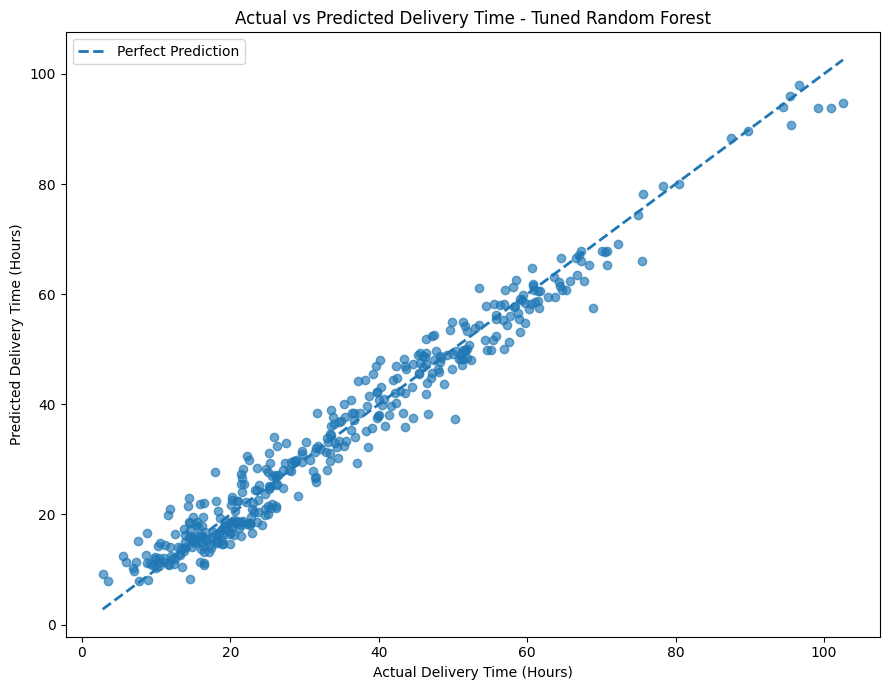

Test observations: 400
Final model MAE: 2.83 hours
Final model RMSE: 3.57 hours
Final model R-squared: 0.968


In [19]:
actual_values = y_test.to_numpy()

minimum_value = min(actual_values.min(), tuned_predictions.min())
maximum_value = max(actual_values.max(), tuned_predictions.max())

plt.figure(figsize=(9, 7))

plt.scatter(
    actual_values,
    tuned_predictions,
    alpha=0.65
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted Delivery Time - Tuned Random Forest")
plt.xlabel("Actual Delivery Time (Hours)")
plt.ylabel("Predicted Delivery Time (Hours)")
plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/Task_4_Actual_vs_Predicted_Delivery_Time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Test observations:", len(actual_values))
print("Final model MAE:", round(tuned_mae, 2), "hours")
print("Final model RMSE:", round(tuned_rmse, 2), "hours")
print("Final model R-squared:", round(tuned_r2, 3))

### Interpretation of Actual vs Predicted Delivery Time

The Actual vs Predicted scatter plot shows that most test observations are positioned relatively close to the 45-degree perfect-prediction reference line. This visual pattern is consistent with the tuned Random Forest's strong aggregate test performance of **MAE = 2.83 hours, RMSE = 3.57 hours, and R² = 0.968**.

Across the main delivery-time range, predicted values generally track increases in actual delivery time closely. This indicates that the model has learned substantial predictive structure from the simulated shipment characteristics rather than simply producing predictions close to the overall average.

### Evidence of Prediction Error

The observations do not fall perfectly on the reference line. Some shipments show visible vertical distance from the line, demonstrating that meaningful prediction errors remain despite the high R².

The plot also suggests that several of the longest-duration shipments are positioned below the perfect-prediction line. This indicates possible **underprediction at the upper end of the delivery-time range**.

This matters because a model can achieve strong overall metrics while still performing less effectively for operationally important extreme shipments.

### Why This Visualization Adds Information Beyond R²

R² summarizes the proportion of target variation explained relative to a mean-based reference, but it does not show where prediction errors occur.

The Actual vs Predicted plot makes it possible to inspect whether errors appear randomly across the target range or become more noticeable for particular types of observations. In this case, the visual evidence suggests generally close agreement alongside some larger deviations and possible underprediction among very long-duration shipments.

### Operational Implication

For logistics planning, an underpredicted long-duration shipment could be more consequential than a similar numerical error on a routine shipment because it may lead to overly optimistic scheduling, resource allocation, or customer delivery expectations.

Therefore, the model should not be used only as a single-point prediction system. In a real deployment, unusually long predicted shipments or shipments with operational risk factors could be flagged for additional review, and prediction uncertainty should be considered when setting service commitments.

### Next Diagnostic Requirement

The Actual vs Predicted plot shows the relationship between predictions and observed outcomes, but it is not the most direct visualization for identifying systematic error patterns.

A **residual plot** will therefore be examined next. Residual analysis will help determine whether errors are centered around zero and whether the magnitude or direction of prediction errors changes across the predicted delivery-time range.

### Limitation

The apparent predictive accuracy reflects performance on held-out observations from the same hypothetical data-generating process used to construct the training data. The visual agreement should therefore be interpreted as internal simulated-model performance rather than evidence of equivalent accuracy in real logistics operations.

### 14.2 Residual Analysis

A **residual scatter plot** is selected to examine the pattern of prediction errors produced by the tuned Random Forest.

A residual is calculated as:

**Residual = Actual Delivery Time − Predicted Delivery Time**

Therefore, a positive residual means the model **underpredicted** the actual delivery time, while a negative residual means the model **overpredicted** it.

The residual plot places predicted delivery time on the horizontal axis and residual error on the vertical axis. A horizontal reference line at zero represents a perfect prediction.

For a well-behaved predictive model, residuals should generally be distributed around zero without a strong systematic pattern. Visible trends, changing error spread, or clusters away from zero could indicate that model performance differs across parts of the prediction range.

This diagnostic complements the Actual vs Predicted plot by focusing directly on the magnitude and direction of prediction errors.

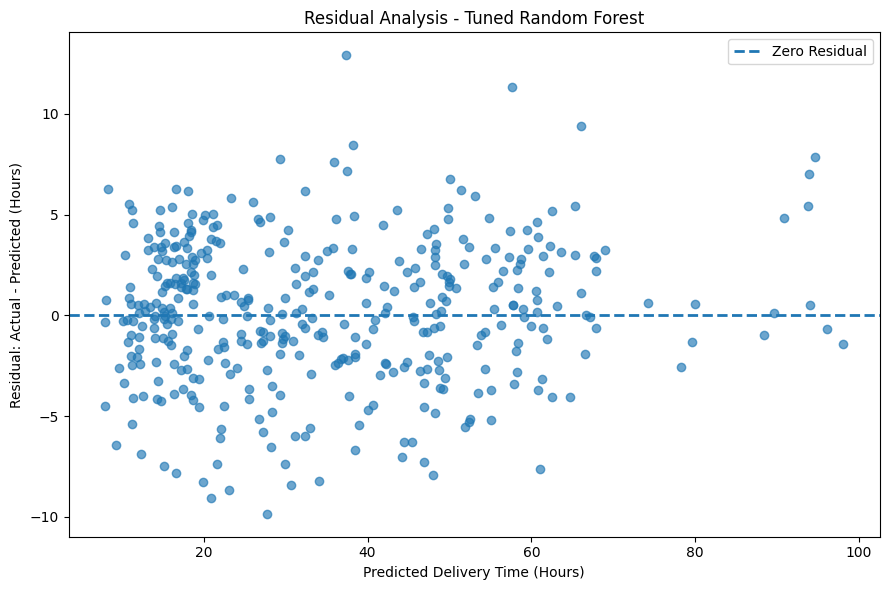

Mean residual: 0.21 hours
Median residual: 0.31 hours
Residual standard deviation: 3.57 hours
Minimum residual: -9.84 hours
Maximum residual: 12.91 hours


In [20]:
residuals = actual_values - tuned_predictions

plt.figure(figsize=(9, 6))

plt.scatter(
    tuned_predictions,
    residuals,
    alpha=0.65
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2,
    label="Zero Residual"
)

plt.title("Residual Analysis - Tuned Random Forest")
plt.xlabel("Predicted Delivery Time (Hours)")
plt.ylabel("Residual: Actual - Predicted (Hours)")
plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/Task_4_Random_Forest_Residual_Plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Mean residual:", round(residuals.mean(), 2), "hours")
print("Median residual:", round(np.median(residuals), 2), "hours")
print("Residual standard deviation:", round(residuals.std(), 2), "hours")
print("Minimum residual:", round(residuals.min(), 2), "hours")
print("Maximum residual:", round(residuals.max(), 2), "hours")

### Interpretation of Residual Analysis

The residual plot provides a direct view of the tuned Random Forest's prediction errors across the range of predicted delivery times.

The residuals are generally distributed on both sides of the zero-error reference line. The **mean residual is 0.21 hours** and the **median residual is 0.31 hours**, both relatively close to zero. This indicates that the model does not show a large overall tendency to systematically overpredict or underpredict delivery time across the complete test sample.

Because residuals are defined as Actual − Predicted, the slightly positive mean residual indicates a small average tendency toward **underprediction**. However, an average bias of 0.21 hours is small relative to the model's MAE of 2.83 hours and residual standard deviation of 3.57 hours.

### Magnitude of Individual Errors

Although average residual bias is small, individual prediction errors are not negligible.

The minimum residual is **−9.84 hours**, meaning that at least one shipment was overpredicted by approximately 9.84 hours. The maximum residual is **12.91 hours**, indicating that at least one shipment was underpredicted by approximately 12.91 hours.

This distinction is important because a near-zero mean residual does not mean that every prediction is close to the actual value. Positive and negative errors can offset one another when calculating an average.

### Visual Pattern

The residual plot does not show a simple strong upward or downward trend across the entire prediction range. This supports the conclusion that there is no obvious large systematic directional bias in the model's predictions.

However, the spread of residuals varies across observations, and some relatively large positive and negative errors remain. The number of observations is also smaller at the highest predicted delivery-time values, so model behavior in that region should be interpreted cautiously.

This finding complements the Actual vs Predicted plot, where some deviations were visible for long-duration shipments.

### Why Residual Analysis Was Necessary

MAE and RMSE describe the overall magnitude of prediction error but cannot show whether errors consistently occur in one direction or whether error patterns change across predicted values.

The residual plot therefore provides a diagnostic function that aggregate metrics cannot provide by themselves. Combining numerical error metrics with residual analysis gives a more complete assessment of model behavior.

### Operational Meaning

In logistics operations, average predictive performance alone may not be sufficient for planning high-risk shipments. Even though the model's typical absolute error is relatively low, individual errors approaching 10–13 hours could materially affect scheduling, resource allocation, service commitments, and customer expectations.

A practical implementation should therefore combine predicted delivery time with operational monitoring or risk thresholds. Shipments with unusually long predicted durations or high-risk operating conditions could be flagged for additional review rather than relying exclusively on a point prediction.

### Limitation

Residual diagnostics are based on only the 400 held-out observations from the same simulated data-generating environment as the training sample. They provide useful internal evidence about model error behavior but do not establish how residual patterns would behave on future real-world logistics data.

### 14.3 Feature Importance Analysis

Model performance metrics explain how accurately the tuned Random Forest predicts delivery time, but they do not explain which input features contribute most strongly to the model's predictions.

A **feature-importance analysis** is therefore used to examine the relative contribution of the transformed predictor variables within the final Random Forest.

A horizontal bar chart is selected because the model contains both numerical predictors and multiple one-hot-encoded categorical features. Horizontal bars make the transformed feature names easier to read and allow their relative importance values to be compared directly.

Random Forest feature importance measures how much each feature contributes to reducing prediction error within the ensemble's decision trees. Higher importance indicates that a feature was used more strongly by the model for prediction.

However, feature importance should not be interpreted as causation. It also does not indicate whether a feature increases or decreases delivery time. The analysis describes predictive contribution within this particular simulated model.

TOP 12 RANDOM FOREST FEATURE IMPORTANCES
----------------------------------------


,Feature,Importance_Percent
0,num__Distance_km,56.61
1,cat__Transport_Mode_Air,23.23
2,cat__Transport_Mode_Sea,13.16
3,num__Warehouse_Processing_Hours,1.45
4,cat__Transport_Mode_Road,1.33
5,cat__Transport_Mode_Rail,1.24
6,num__Shipment_Volume_kg,0.76
7,cat__Traffic_Level_High,0.44
8,cat__Weather_Condition_Storm,0.41
9,cat__Weather_Condition_Clear,0.25


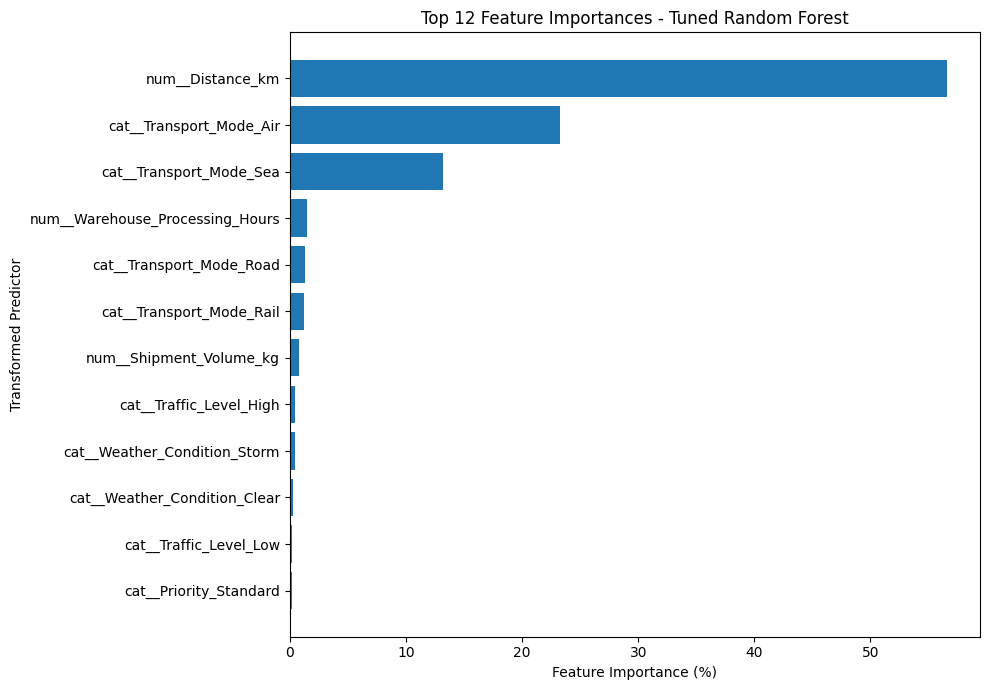

In [21]:
fitted_preprocessor = tuned_random_forest.named_steps["preprocessor"]
fitted_forest = tuned_random_forest.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()
importance_values = fitted_forest.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df["Importance_Percent"] = (
    feature_importance_df["Importance"] * 100
).round(2)

print("TOP 12 RANDOM FOREST FEATURE IMPORTANCES")
print("----------------------------------------")

display(
    feature_importance_df[
        ["Feature", "Importance_Percent"]
    ].head(12)
)

top_features = feature_importance_df.head(12).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance_Percent"]
)

plt.title("Top 12 Feature Importances - Tuned Random Forest")
plt.xlabel("Feature Importance (%)")
plt.ylabel("Transformed Predictor")
plt.tight_layout()

plt.savefig(
    "/content/Task_4_Random_Forest_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
print("TOP 12 FEATURE IMPORTANCE VALUES")
print("--------------------------------")

for _, row in feature_importance_df.head(12).iterrows():
    print(
        row["Feature"],
        ":",
        round(row["Importance_Percent"], 2),
        "%"
    )

TOP 12 FEATURE IMPORTANCE VALUES
--------------------------------
num__Distance_km : 56.61 %
cat__Transport_Mode_Air : 23.23 %
cat__Transport_Mode_Sea : 13.16 %
num__Warehouse_Processing_Hours : 1.45 %
cat__Transport_Mode_Road : 1.33 %
cat__Transport_Mode_Rail : 1.24 %
num__Shipment_Volume_kg : 0.76 %
cat__Traffic_Level_High : 0.44 %
cat__Weather_Condition_Storm : 0.41 %
cat__Weather_Condition_Clear : 0.25 %
cat__Traffic_Level_Low : 0.21 %
cat__Priority_Standard : 0.19 %


### Interpretation of Feature Importance

The tuned Random Forest assigns substantially different levels of predictive importance to the transformed shipment features.

**Shipment distance is the dominant individual predictor**, accounting for **56.61%** of the model's impurity-based feature importance. This is consistent with the earlier exploratory analysis, where Distance_km had a Pearson correlation of **0.712** with delivery time. Within the simulation, distance directly contributes to transit duration, so its strong predictive role is expected.

Transportation mode is also highly influential. The one-hot-encoded **Air** indicator accounts for **23.23%** of importance, while **Sea** contributes **13.16%**. The Road and Rail indicators contribute **1.33%** and **1.24%**, respectively.

These results are consistent with the earlier box-plot analysis, which showed substantial differences in delivery-time distributions across transport modes. Air shipments had an average simulated delivery time of **15.36 hours**, whereas Sea shipments averaged **54.54 hours**.

Importantly, the importance values of individual one-hot-encoded categories should not be interpreted as a complete ranking of the underlying transportation modes. They represent how the fitted trees used particular encoded indicators when constructing predictions. The broader conclusion is that **transportation mode as a feature group provides substantial predictive information**.

**Warehouse processing time** contributes **1.45%** of model importance. Earlier Pearson correlation between warehouse processing and delivery time was only **0.084**. This difference illustrates why correlation and model-based feature importance answer different questions. Pearson correlation measures a pairwise linear relationship, whereas Random Forest can use a variable conditionally and through nonlinear interactions with other predictors.

**Shipment volume** contributes only **0.76%**, consistent with its near-zero Pearson correlation of **0.001** with delivery time. Within this simulated prediction problem, shipment volume therefore provides relatively little predictive information compared with distance and transportation mode.

Traffic and weather indicators have smaller individual importance values in the fitted model. For example, High Traffic contributes **0.44%**, Storm conditions **0.41%**, Clear weather **0.25%**, and Low Traffic **0.21%** among the displayed features. Priority Standard contributes **0.19%**.

### Why Small Importance Does Not Mean No Operational Effect

A low feature-importance value should not automatically be interpreted as evidence that an operational factor is irrelevant.

Importance is influenced by the strength of the feature's relationship with the target, interactions with other predictors, the number and form of available features, and how frequently a variable is selected for useful tree splits.

Additionally, categorical variables are represented by multiple one-hot-encoded columns. Their predictive contribution can therefore be distributed across several transformed features rather than appearing as one single importance value.

### Comparison with Correlation Analysis

The feature-importance analysis provides information that the earlier numerical correlation analysis could not capture.

Distance showed both a strong Pearson correlation and high model importance, providing consistent evidence of strong predictive relevance within the simulation.

Warehouse processing, by contrast, had a weak pairwise correlation but still contributed to the Random Forest predictions. Transportation mode could not be represented meaningfully in the numerical Pearson correlation table at all, yet its encoded categories account for substantial model importance.

This demonstrates why feature assessment should not rely on a single analytical method.

### Operational Interpretation

The model indicates that shipment distance and transportation mode are central inputs for forecasting delivery duration within this simulated logistics environment.

Operationally, this suggests that delivery-time planning should account for the interaction between route distance and available transportation options rather than applying one uniform expected delivery duration across shipments.

Warehouse processing, traffic, weather, priority, and shipment characteristics can provide additional shipment-specific information, even though their individual importance values are considerably smaller in this fitted model.

### Important Methodological Limitation

Random Forest's built-in feature importance is an **impurity-based importance measure**. It describes how strongly features were used to reduce prediction error within the fitted ensemble, but it does not establish causal effects, indicate the direction of an effect, or guarantee that importance would remain the same in another dataset.

The values also reflect relationships intentionally incorporated into the hypothetical data-generation process. Therefore, they should be interpreted as explanations of this simulated predictive model rather than empirical estimates of real-world logistics drivers.

For a real deployment, model interpretation could be strengthened with additional techniques such as permutation importance or SHAP analysis and validated using actual operational data.

## 15. Predictive Modeling for Logistics Optimization

Predictive accuracy becomes operationally useful when model outputs are connected to specific logistics decisions. In this project, the tuned Random Forest is therefore used not only to estimate delivery duration but also to demonstrate how predicted delivery times could support shipment planning and optimization.

### 15.1 Optimization Objective

The primary optimization objective is to support **delivery-time reduction and more informed transportation planning** while recognizing that operational decisions normally involve multiple constraints.

The predictive model can estimate delivery time under different combinations of shipment characteristics. This makes it possible to evaluate hypothetical operational scenarios before a shipment is completed.

The optimization framework focuses on four decision areas:

1. **Transportation-mode planning:** Compare predicted delivery times under alternative feasible transportation modes for the same shipment characteristics.

2. **Warehouse processing improvement:** Identify whether reducing processing time could meaningfully improve predicted end-to-end delivery duration.

3. **Risk-based shipment prioritization:** Use predicted delivery duration to identify shipments that may require earlier operational attention.

4. **Resource allocation:** Direct operational attention toward shipment conditions associated with longer predicted delivery durations rather than allocating resources uniformly.

### Prediction vs Optimization

The predictive model itself does not automatically determine the optimal logistics decision.

Prediction answers:

**“What delivery time is expected under these shipment characteristics?”**

Optimization asks:

**“Which feasible operational decision should be selected given business objectives and constraints?”**

This distinction is important because minimizing delivery time alone may not produce the most practical logistics decision. Transportation cost, capacity, service requirements, route availability, environmental considerations, contractual commitments, and operational constraints may also influence the final choice.

### Scenario-Based Optimization Approach

To demonstrate the connection between prediction and optimization, selected shipment scenarios will be evaluated under alternative operational conditions while holding other characteristics constant.

This creates a controlled **what-if analysis**. For example, the same shipment can be evaluated under Road, Rail, Air, and Sea transportation settings to compare the model's predicted delivery times.

The scenario results will be interpreted as **model-based decision support**, not as causal estimates or guaranteed real-world outcomes.

### Optimization Boundary

Because the hypothetical dataset does not contain transportation cost, route capacity, vehicle availability, fuel consumption, or contractual constraints, this project cannot claim to solve a complete real-world cost-and-service optimization problem.

Instead, the analysis demonstrates how predictive delivery-time estimates could form one component of a broader logistics optimization system. A real implementation would combine these predictions with cost and operational constraints in an optimization algorithm.

### 15.2 Transportation Mode What-If Analysis

A controlled what-if analysis is used to demonstrate how the predictive model could support transportation-mode planning.

A representative hypothetical shipment is defined using fixed operational characteristics. The transportation mode is then changed across Air, Rail, Road, and Sea while all other predictor values remain constant.

Holding the other characteristics constant allows the model's predicted delivery times under the four mode scenarios to be compared consistently.

This analysis does not prove that changing transportation mode would causally produce the predicted difference in a real logistics operation. Instead, it demonstrates how a trained predictive model can be used as a decision-support tool for evaluating alternative planning scenarios within the simulated environment.

Transportation cost is not included in the current hypothetical dataset. Therefore, the scenario identifies delivery-time differences only and should not be interpreted as a complete mode-selection optimization. A real decision would also require cost, capacity, availability, service-level, and route constraints.

In [23]:
scenario_base = {
    "Distance_km": 1500,
    "Shipment_Volume_kg": 300,
    "Warehouse_Processing_Hours": 4.0,
    "Region": "North",
    "Priority": "Standard",
    "Traffic_Level": "Medium",
    "Weather_Condition": "Clear"
}

scenario_rows = []

for mode in ["Air", "Rail", "Road", "Sea"]:
    scenario = scenario_base.copy()
    scenario["Transport_Mode"] = mode
    scenario_rows.append(scenario)

mode_scenarios = pd.DataFrame(scenario_rows)

mode_scenarios["Predicted_Delivery_Time_Hours"] = (
    tuned_random_forest.predict(mode_scenarios)
)

mode_results = mode_scenarios[
    ["Transport_Mode", "Predicted_Delivery_Time_Hours"]
].copy()

mode_results["Predicted_Delivery_Time_Hours"] = (
    mode_results["Predicted_Delivery_Time_Hours"].round(2)
)

mode_results = mode_results.sort_values(
    "Predicted_Delivery_Time_Hours"
).reset_index(drop=True)

print("TRANSPORT MODE WHAT-IF ANALYSIS")
print("-------------------------------")
print("Scenario: 1500 km, 300 kg, 4-hour warehouse processing,")
print("North region, Standard priority, Medium traffic, Clear weather")
print()

display(mode_results)

TRANSPORT MODE WHAT-IF ANALYSIS
-------------------------------
Scenario: 1500 km, 300 kg, 4-hour warehouse processing,
North region, Standard priority, Medium traffic, Clear weather



,Transport_Mode,Predicted_Delivery_Time_Hours
0,Air,13.87
1,Rail,28.81
2,Road,34.36
3,Sea,54.08


### Interpretation of Transportation Mode What-If Analysis

The controlled scenario demonstrates how the tuned Random Forest can be used to compare predicted delivery durations under alternative transportation-mode settings while holding the remaining shipment characteristics constant.

For the representative 1,500 km, 300 kg shipment with 4 hours of warehouse processing, North region, Standard priority, Medium traffic, and Clear weather, the predicted delivery times are:

- **Air: 13.87 hours**
- **Rail: 28.81 hours**
- **Road: 34.36 hours**
- **Sea: 54.08 hours**

Relative to Road, the model predicts Air to be **20.49 hours shorter**, while Rail is predicted to be **5.55 hours shorter**. Sea is predicted to require **19.72 hours longer** than Road for this particular scenario.

### Optimization Interpretation

If minimizing delivery duration were the only objective and all transportation modes were operationally feasible, the scenario indicates that the model would associate Air with the shortest predicted delivery time.

However, this does **not** establish Air as the universally optimal transportation mode.

A real logistics decision is normally multi-objective. Air transportation may involve different costs, capacity constraints, route availability, shipment restrictions, environmental impacts, and service requirements. These variables are not represented in the current hypothetical dataset.

Therefore, the appropriate decision-support use of this model is to provide a predicted delivery-time component that can be combined with other operational criteria.

For example, if a shipment has a strict service deadline, planners could compare the predicted delivery time of feasible modes and then select among the modes that satisfy the deadline using additional cost and capacity information.

### Practical Decision Rule

A possible operational workflow would be:

**Step 1:** Predict expected delivery duration under each feasible transportation mode.

**Step 2:** Remove modes whose predicted delivery duration exceeds the required service deadline.

**Step 3:** Among the remaining feasible options, evaluate transportation cost, capacity, route availability, and other business constraints.

**Step 4:** Select the option that provides the preferred balance between service performance and operational cost.

This converts the predictive model into a decision-support component without incorrectly treating prediction alone as a complete optimization algorithm.

### Limitation of the Scenario

This is a model-based what-if comparison, not a randomized experiment or causal estimate. Changing only the Transport_Mode field assumes that the remaining shipment characteristics can realistically remain unchanged across modes.

In real operations, mode changes may also affect cost, routing, handling requirements, warehouse schedules, and other variables. Consequently, the numerical differences should be interpreted as simulated scenario outputs rather than guaranteed savings in delivery time.

### 15.3 Warehouse Processing Optimization Scenario

Warehouse processing is an operational variable that may be more directly controllable than shipment distance or external weather conditions. Therefore, a second what-if analysis evaluates how different warehouse processing times affect predicted delivery duration while the other shipment characteristics remain fixed.

A representative Road shipment is evaluated using warehouse processing times of 2, 4, 6, 8, and 10 hours.

This scenario demonstrates how predictive modeling could support warehouse improvement decisions. If reductions in processing time are associated with meaningful reductions in predicted total delivery duration, managers could use such information when prioritizing process-improvement initiatives.

However, the results remain model-based scenario estimates. They do not establish the causal effect that would occur from physically reducing warehouse processing time in a real logistics operation.

WAREHOUSE PROCESSING WHAT-IF ANALYSIS
-------------------------------------


,Warehouse_Processing_Hours,Predicted_Delivery_Time_Hours
0,2,34.07
1,4,34.36
2,6,36.62
3,8,36.82
4,10,37.70


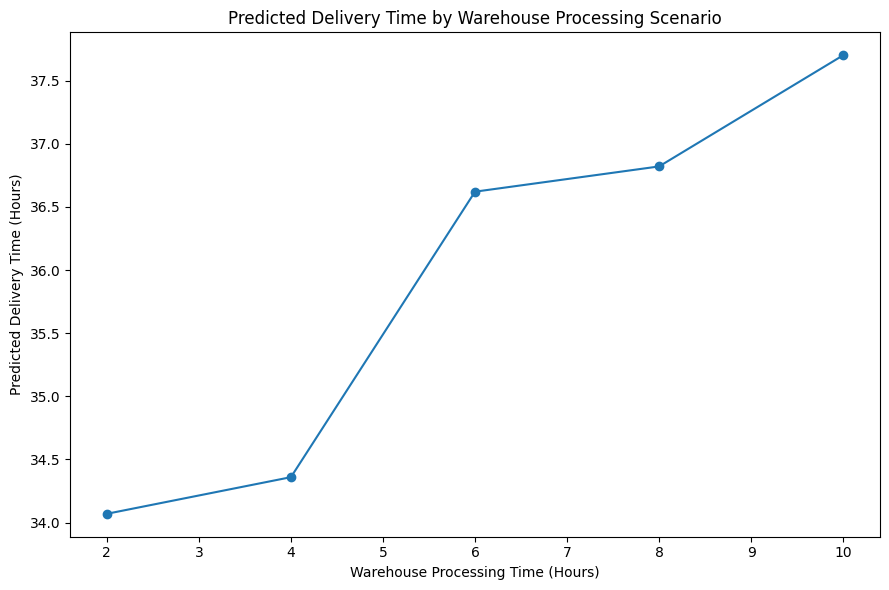

In [24]:
warehouse_times = [2, 4, 6, 8, 10]

warehouse_scenarios = pd.DataFrame({
    "Distance_km": [1500] * 5,
    "Shipment_Volume_kg": [300] * 5,
    "Warehouse_Processing_Hours": warehouse_times,
    "Region": ["North"] * 5,
    "Transport_Mode": ["Road"] * 5,
    "Priority": ["Standard"] * 5,
    "Traffic_Level": ["Medium"] * 5,
    "Weather_Condition": ["Clear"] * 5
})

warehouse_scenarios["Predicted_Delivery_Time_Hours"] = (
    tuned_random_forest.predict(warehouse_scenarios)
)

warehouse_results = warehouse_scenarios[
    ["Warehouse_Processing_Hours", "Predicted_Delivery_Time_Hours"]
].copy()

warehouse_results["Predicted_Delivery_Time_Hours"] = (
    warehouse_results["Predicted_Delivery_Time_Hours"].round(2)
)

print("WAREHOUSE PROCESSING WHAT-IF ANALYSIS")
print("-------------------------------------")

display(warehouse_results)

plt.figure(figsize=(9, 6))

plt.plot(
    warehouse_results["Warehouse_Processing_Hours"],
    warehouse_results["Predicted_Delivery_Time_Hours"],
    marker="o"
)

plt.title("Predicted Delivery Time by Warehouse Processing Scenario")
plt.xlabel("Warehouse Processing Time (Hours)")
plt.ylabel("Predicted Delivery Time (Hours)")
plt.tight_layout()

plt.savefig(
    "/content/Task_4_Warehouse_Processing_Optimization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation of Warehouse Processing Optimization Scenario

The warehouse-processing what-if analysis shows that predicted total delivery time generally increases as warehouse processing time increases for the controlled Road shipment scenario.

At **2 hours** of warehouse processing, the model predicts a total delivery time of **34.07 hours**. The prediction increases to **34.36 hours** at 4 processing hours, **36.62 hours** at 6 hours, **36.82 hours** at 8 hours, and **37.70 hours** at 10 hours.

Across the full scenario range, increasing warehouse processing time from 2 to 10 hours is associated with a **3.63-hour increase in predicted total delivery time**.

### Why the Pattern Is Not Perfectly Linear

The predicted relationship is not a straight line. For example, the change in predicted delivery time between 4 and 6 processing hours is larger than the change between 6 and 8 hours.

This is consistent with the behavior of a Random Forest model. Unlike Linear Regression, Random Forest does not impose a constant linear coefficient on warehouse processing time. Its predictions are generated from many decision-tree splits and can therefore change in steps or nonlinear patterns depending on how the fitted trees partition the feature space.

The result should consequently be interpreted as the response of the fitted predictive model to these specific scenario inputs rather than as a claim that every one-hour warehouse reduction produces a fixed number of hours of delivery-time improvement.

### Connection with Earlier Analysis

Earlier Pearson correlation analysis showed only a weak pairwise relationship between warehouse processing and delivery time (**r = 0.084**), while Random Forest feature importance assigned warehouse processing **1.45%** of total impurity-based importance.

The scenario analysis adds another perspective. Although warehouse processing is much less influential than shipment distance and transportation mode in the overall model, changing its value can still alter the predicted delivery time for a specific shipment configuration.

This demonstrates why operational decisions should not be based only on global correlation coefficients or feature-importance rankings.

### Optimization Implication

Warehouse processing is potentially more operationally controllable than factors such as shipment distance or weather. Therefore, reducing avoidable warehouse processing delays may provide a practical improvement opportunity even though warehouse processing is not the dominant predictor in the model.

However, the model does not show that warehouse processing should be minimized without constraint. Faster processing could require additional labor, automation, equipment, or scheduling resources.

A real optimization decision should compare the expected service-time benefit of reducing processing time with the cost and feasibility of achieving that reduction.

### Practical Recommendation

Logistics managers could use predicted delivery duration together with warehouse workload information to identify shipments where processing-time reductions are most valuable.

Rather than applying the same processing target to every shipment, operational resources could be prioritized toward shipments with tight service deadlines or high predicted delivery durations, provided that the expected service benefit justifies the additional resource requirement.

### Limitation

This analysis is a model-based what-if scenario rather than a causal experiment. The predicted 3.63-hour difference across the 2-to-10-hour processing range should not be interpreted as a guaranteed real-world time saving.

Real warehouse interventions would need to be validated using operational data, process constraints, staffing requirements, and implementation costs.

## 16. Actionable Logistics Optimization Recommendations

The predictive modeling and scenario analyses provide several opportunities for improving logistics planning within the simulated environment. The recommendations below are linked directly to analytical evidence rather than being presented as generic logistics practices.

### 1. Use Predicted Delivery Time as a Pre-Shipment Planning KPI

The tuned Random Forest achieved a test MAE of **2.83 hours**, RMSE of **3.57 hours**, and R² of **0.968** within the simulated dataset.

The model could therefore be used as a pre-shipment decision-support tool to estimate expected delivery duration from shipment characteristics available during planning.

Shipments with unusually high predicted delivery times could be flagged for additional operational review before dispatch.

**Implementation approach:** Integrate the prediction pipeline into shipment-planning workflows and establish business-defined thresholds for identifying shipments requiring intervention.

### 2. Evaluate Transportation Mode Against Service Requirements

Transportation mode was one of the strongest predictive components of the final model.

In the controlled 1,500 km scenario, predicted delivery times ranged from **13.87 hours for Air** to **54.08 hours for Sea**, while Rail and Road were predicted at **28.81 and 34.36 hours**, respectively.

Instead of automatically selecting the fastest predicted mode, planners should first identify transportation modes capable of satisfying the required delivery deadline and then compare those feasible options using cost, capacity, availability, and other operational constraints.

This creates a more realistic **service-constrained mode-selection strategy**.

### 3. Prioritize Distance-Sensitive Shipment Planning

Shipment distance accounts for **56.61%** of the final model's impurity-based feature importance and has a Pearson correlation of **0.712** with delivery time.

Long-distance shipments should therefore receive particular attention during delivery-time planning because distance is a major source of predictive variation within the simulated system.

Potential actions include earlier dispatch planning, mode evaluation, route review, and additional schedule buffers for shipments with high predicted delivery durations.

### 4. Target Warehouse Improvements Where Service Benefits Are Material

Warehouse processing contributes less predictive importance than distance and transportation mode, but the controlled scenario demonstrates that it can still affect shipment-level predictions.

For the representative Road scenario, predicted delivery time increased from **34.07 hours at 2 processing hours** to **37.70 hours at 10 processing hours**, a difference of **3.63 hours**.

Warehouse improvement initiatives should therefore be targeted rather than applied uniformly. Priority could be given to shipments with tight deadlines or high predicted delivery durations where processing-time reductions are likely to provide greater operational value.

### 5. Introduce Risk-Based Operational Review

Although the final model's average absolute error is relatively low, residual analysis identified individual errors ranging from **−9.84 to +12.91 hours**.

This means that point predictions should not be treated as exact delivery guarantees.

A practical system could combine predicted delivery time with risk rules. Shipments with long predicted durations, unusual operating conditions, or strict service commitments could be escalated for human review and closer monitoring.

### 6. Use Multiple Performance Measures for Model Monitoring

Model monitoring should not rely only on R².

MAE should be tracked because it communicates typical prediction error directly in hours. RMSE should also be monitored because it is more sensitive to large errors that may be operationally important.

Residual patterns should be reviewed periodically to identify systematic underprediction, overprediction, or changes in error behavior.

### 7. Retrain and Revalidate the Model as Operations Change

A real logistics environment can change because of new routes, transportation capacity, seasonal conditions, customer demand, warehouse processes, or service policies.

A deployed model should therefore be monitored for performance drift and periodically retrained using recent verified operational data.

Any updated model should be evaluated against the existing model on unseen data before replacement.

### 8. Extend Prediction into Multi-Objective Optimization

The current project optimizes decision support primarily around predicted delivery duration.

A more complete logistics optimization framework should add variables such as:

- Transportation cost
- Vehicle and mode capacity
- Route availability
- Fuel or energy consumption
- Service-level deadlines
- Warehouse capacity
- Labor availability
- Environmental impact

The predictive model could then provide estimated delivery time to an optimization algorithm whose objective balances service performance with cost and operational constraints.

Possible future optimization techniques include linear programming, mixed-integer programming, vehicle-routing algorithms, or constrained optimization depending on the business problem.

## Implementation Principle

The model should support logistics professionals rather than automatically replace operational judgment.

Predictions provide quantitative evidence about expected delivery duration, while optimization decisions require additional information about cost, feasibility, service commitments, and operational constraints.

The recommended workflow is therefore:

**Predict → Identify Risk → Evaluate Feasible Alternatives → Apply Business Constraints → Select Operational Action → Monitor Outcome**

This approach connects predictive analytics with practical logistics decision-making while recognizing the limitations of the available simulated data.

## 17. Consolidated Analytical Findings and KPI Summary

The predictive modeling workflow produced a set of quantitative findings that connect exploratory analysis, model evaluation, validation, diagnostics, and logistics optimization.

| Analytical Area | Quantitative Evidence | Interpretation | Operational Implication |
|---|---|---|---|
| Dataset Quality | 2,000 shipments, 11 variables, 0 missing values, 0 duplicate rows | The simulated dataset is complete and structurally suitable for the modeling workflow | Modeling can proceed without data-loss treatment, while preprocessing remains designed to handle future missing values |
| Delivery-Time Target | Mean = 34.99 h; Median = 31.26 h; SD = 19.62 h; Range = 2.39–105.35 h | Delivery duration shows substantial variability and a longer-duration tail | Long-duration shipments require particular attention during prediction and planning |
| Distance Relationship | Pearson r = 0.712 with delivery time | Distance has a strong positive linear association with delivery duration within the simulation | Distance-sensitive planning should be incorporated into delivery estimates |
| Transport Mode | Air mean = 15.36 h; Rail = 32.58 h; Road = 37.90 h; Sea = 54.54 h | Delivery-time distributions differ substantially by mode | Mode information is important for forecasting and scenario planning |
| Baseline Model | MAE = 16.61 h; RMSE = 19.97 h; R² ≈ 0 | Mean-only prediction provides poor shipment-specific information | Candidate models must materially outperform this reference |
| Linear Regression | MAE = 5.10 h; RMSE = 7.22 h; R² = 0.869 | A simple additive model captures substantial predictive structure | Selected predictors contain meaningful delivery-time information |
| Decision Tree | MAE = 4.18 h; RMSE = 5.32 h; R² = 0.929 | Nonlinear modeling improves performance over Linear Regression | Interactions and nonlinear relationships contribute predictive value |
| Untuned Random Forest | MAE = 2.85 h; RMSE = 3.61 h; R² = 0.967 | Ensemble modeling provides the strongest initial test performance | Random Forest becomes the leading candidate for validation and tuning |
| Cross-Validation | Random Forest CV MAE = 3.10 ± 0.11 h | Random Forest maintains relatively stable accuracy across five folds | Strong performance is not limited to one train-test split |
| Hyperparameter Tuning | CV MAE improved from 3.10 h to 3.04 h, a 1.99% improvement | Tuning provides a measurable but modest improvement | Additional complexity should be justified by its limited incremental benefit |
| Final Tuned Model | MAE = 2.83 h; RMSE = 3.57 h; R² = 0.968 | Tuned Random Forest provides the strongest validated performance within the simulation | Selected as the final predictive model |
| Residual Diagnostics | Mean residual = 0.21 h; residual range = −9.84 to +12.91 h | Overall directional bias is small, but meaningful individual errors remain | Point predictions should be combined with risk monitoring rather than treated as guarantees |
| Feature Importance | Distance = 56.61%; Air indicator = 23.23%; Sea indicator = 13.16% | Distance and transportation mode dominate predictive contribution | Route distance and feasible mode alternatives deserve particular planning attention |
| Mode What-If Scenario | Air = 13.87 h; Rail = 28.81 h; Road = 34.36 h; Sea = 54.08 h | Predicted delivery duration changes substantially across mode scenarios | Mode selection should combine predicted service time with cost and feasibility constraints |
| Warehouse Scenario | 2 h processing → 34.07 h predicted delivery; 10 h → 37.70 h | An 8-hour processing difference corresponds to a 3.63-hour prediction difference in the controlled scenario | Target warehouse improvements where service benefits justify resource requirements |

### Overall Analytical Synthesis

The results show that predictive modeling can provide substantially more shipment-specific delivery-time information than a simple mean-based baseline within the hypothetical logistics environment.

Linear Regression establishes that the selected predictors contain strong predictive information, while the Decision Tree and Random Forest results demonstrate additional value from nonlinear relationships and interactions.

The tuned Random Forest provides the strongest overall evidence, combining low held-out test error, stable cross-validation performance, and a modest improvement following systematic hyperparameter tuning.

Model diagnostics also demonstrate why high aggregate performance should not be interpreted as perfect prediction. Individual residual errors remain meaningful, particularly for operational decisions where underestimating delivery duration could affect service commitments.

The optimization scenarios illustrate how predictive outputs can support transportation-mode evaluation and warehouse-process decisions. However, prediction alone does not solve the complete logistics optimization problem. Real implementation would require additional cost, capacity, routing, service-level, and operational constraints.

Therefore, the primary value of the final model is as a **predictive decision-support component within a broader logistics planning and optimization framework**, rather than as an autonomous decision-making system.

## 18. Feasibility, Limitations, and Real-World Implementation

### 18.1 Implementation Feasibility

The predictive workflow developed in this project is technically feasible as a prototype because it uses standard Python machine-learning tools and a reproducible preprocessing-and-modeling pipeline.

In a real logistics organization, a similar system could receive shipment characteristics from a transportation management system, warehouse management system, or operational database and return an estimated delivery duration during shipment planning.

However, technical feasibility does not automatically establish business readiness. Before deployment, the model would require validation using actual historical shipment data and integration with existing operational processes.

### 18.2 Data Requirements for Real Deployment

A production implementation should use verified historical logistics data containing variables available at prediction time. Useful additional variables could include transportation cost, route characteristics, carrier performance, vehicle capacity, congestion information, warehouse workload, seasonal demand, service-level requirements, and real weather information.

Data quality controls would also be required for missing values, incorrect records, category changes, extreme observations, and inconsistent measurement definitions.

### 18.3 Key Limitations

**Simulated data:** The complete analysis is based on a hypothetical dataset. Model performance therefore reflects the relationships intentionally created during simulation rather than independently observed real-world logistics behavior.

**Internal rather than external validation:** Train-test evaluation and cross-validation were performed using observations generated from the same simulation process. No independent real logistics dataset was available for external validation.

**Limited optimization variables:** Transportation cost, route capacity, vehicle availability, labor cost, fuel consumption, and service penalties are not included. Therefore, the project demonstrates delivery-time decision support rather than a complete cost-and-service optimization system.

**Feature-importance limitation:** Random Forest impurity-based importance explains how strongly features were used by the fitted model but does not establish causal effects or indicate the direction of those effects.

**Residual risk:** Although average predictive error is relatively low within the simulation, individual residuals range from −9.84 to +12.91 hours. Operational users should therefore avoid treating predictions as guaranteed delivery times.

**Changing operating conditions:** A model trained on historical data may become less reliable when routes, carriers, customer demand, warehouse processes, weather patterns, or transportation networks change.

### 18.4 Model Monitoring

A real implementation should continuously compare predictions with completed shipment outcomes.

Monitoring should include MAE, RMSE, residual patterns, performance across important shipment segments, missing-data rates, and changes in predictor distributions.

If performance deteriorates beyond business-defined thresholds, the model should be investigated, retrained, and revalidated before an updated version is deployed.

### 18.5 Human Oversight

The model should function as a decision-support tool rather than an autonomous logistics decision maker.

Operational planners should retain responsibility for evaluating constraints not represented in the model, including urgent customer requirements, route disruptions, transportation availability, capacity limitations, contractual obligations, and unusual operating events.

## 19. Conclusion and Reflection

This project developed an end-to-end predictive modeling framework for forecasting shipment delivery time within a hypothetical logistics environment.

The workflow progressed from problem definition and data simulation through exploratory analysis, preprocessing, baseline evaluation, multiple regression models, cross-validation, hyperparameter tuning, diagnostic analysis, feature interpretation, and scenario-based optimization.

Among the evaluated approaches, the tuned Random Forest provided the strongest validated performance, achieving a held-out test **MAE of 2.83 hours, RMSE of 3.57 hours, and R² of 0.968**. Five-fold cross-validation also demonstrated relatively stable Random Forest performance, while hyperparameter tuning produced a modest additional improvement.

The analysis demonstrates that strong predictive performance should not be evaluated from a single metric or model run. Baseline comparison, multiple error measures, cross-validation, residual diagnostics, and explicit limitations are necessary for a more defensible assessment.

The optimization scenarios further demonstrate that prediction and optimization are related but distinct activities. Delivery-time predictions can support transportation-mode evaluation, warehouse planning, shipment prioritization, and resource allocation, but real optimization requires additional information about cost, capacity, feasibility, and service constraints.

Overall, the project demonstrates how predictive analytics can be translated into structured logistics decision support while maintaining appropriate caution about model uncertainty, simulated data, and real-world implementation requirements.

In [25]:
print("FINAL TASK 4 VALIDATION")
print("-----------------------")

print("Dataset rows:", df.shape[0])
print("Dataset columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nFINAL MODEL")
print("Model: Tuned Random Forest Regressor")
print("Test MAE:", round(tuned_mae, 2), "hours")
print("Test RMSE:", round(tuned_rmse, 2), "hours")
print("Test R-squared:", round(tuned_r2, 3))

print("\nCROSS-VALIDATION AND TUNING")
print("Untuned Random Forest CV MAE:", round(cv_mae_before, 2), "hours")
print("Tuned Random Forest CV MAE:", round(cv_mae_after, 2), "hours")
print("CV MAE improvement:", round(cv_improvement, 2), "%")

print("\nRESIDUAL DIAGNOSTICS")
print("Mean residual:", round(residuals.mean(), 2), "hours")
print("Minimum residual:", round(residuals.min(), 2), "hours")
print("Maximum residual:", round(residuals.max(), 2), "hours")

print("\nKEY MODEL DRIVER")
print(
    "Distance feature importance:",
    round(
        feature_importance_df.loc[
            feature_importance_df["Feature"] == "num__Distance_km",
            "Importance_Percent"
        ].iloc[0],
        2
    ),
    "%"
)

print("\nValidation completed successfully.")

FINAL TASK 4 VALIDATION
-----------------------
Dataset rows: 2000
Dataset columns: 11
Missing values: 0
Duplicate rows: 0

FINAL MODEL
Model: Tuned Random Forest Regressor
Test MAE: 2.83 hours
Test RMSE: 3.57 hours
Test R-squared: 0.968

CROSS-VALIDATION AND TUNING
Untuned Random Forest CV MAE: 3.1 hours
Tuned Random Forest CV MAE: 3.04 hours
CV MAE improvement: 1.99 %

RESIDUAL DIAGNOSTICS
Mean residual: 0.21 hours
Minimum residual: -9.84 hours
Maximum residual: 12.91 hours

KEY MODEL DRIVER
Distance feature importance: 56.61 %

Validation completed successfully.


In [26]:
import glob
import zipfile

chart_files = glob.glob("/content/Task_4_*.png")

with zipfile.ZipFile("/content/Task_4_Charts.zip", "w") as zipf:
    for file in chart_files:
        zipf.write(file, arcname=file.split("/")[-1])

print("ZIP created successfully.")
print("Charts included:", len(chart_files))

for file in chart_files:
    print(file.split("/")[-1])

ZIP created successfully.
Charts included: 6
Task_4_Delivery_Time_by_Transport_Mode.png
Task_4_Random_Forest_Residual_Plot.png
Task_4_Delivery_Time_Distribution.png
Task_4_Random_Forest_Feature_Importance.png
Task_4_Actual_vs_Predicted_Delivery_Time.png
Task_4_Warehouse_Processing_Optimization.png
